In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
from e2e.prediction.end_to_end import DataLoader
MAC_DATA_DIR = Path("/Users/magnus/datasets/WAAM/test")
from e2e.data.resampled import ResampledShapeDataset, ResampledE2EDataset
from e2e.data.loader import EXPERIMENT as EXP
import numpy as np

In [6]:
data_loader = DataLoader(MAC_DATA_DIR)
cross_section_samples = data_loader.load_samples([EXP.RANDOM_EX6])
dataset = ResampledE2EDataset(mirror=False, segment_length=90).create(cross_section_samples)

100%|██████████| 56/56 [00:05<00:00,  9.65it/s]


In [26]:
STEP = 17

input_ = cross_section_samples[STEP].slice_based_before.ys
curr_torch = dataset.torchpositions[STEP]
true_fp = dataset.true_footprints[STEP]
left_fp = 112 - np.abs(curr_torch - true_fp.left_idx)
right_fp = 112 + np.abs(curr_torch - true_fp.right_idx)

(-0.32000000000000006,
 6.720000000000001,
 -3.0580307376491125,
 -3.001573225524792)

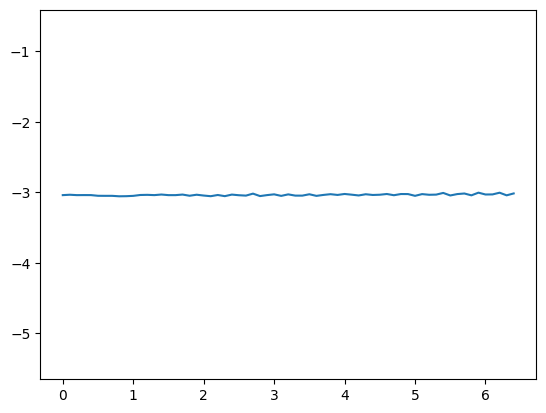

In [27]:
xs = np.arange(0, right_fp - left_fp) / 10
plt.plot(xs, input_.squeeze()[left_fp:right_fp])
plt.axis('equal')


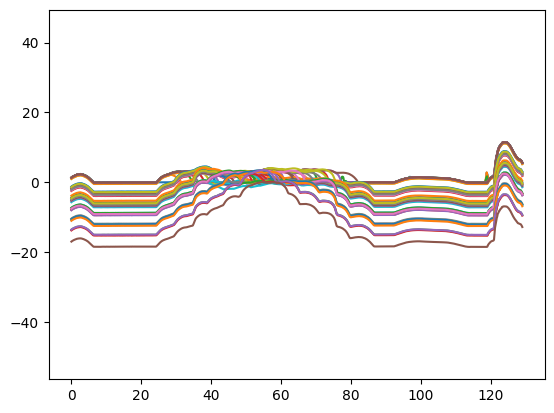

In [39]:
for i in range(len(dataset)):
    input_ = dataset.ground_truth[i]
    curr_torch = dataset.torchpositions[i]
    true_fp = dataset.true_footprints[i]
    left_fp = 112 - np.abs(curr_torch - true_fp.left_idx)
    right_fp = 112 + np.abs(curr_torch - true_fp.right_idx)
    xs = np.arange(0, len(input_)) / 10
    plt.plot(xs, input_.squeeze())
    plt.axis('equal')

plt.show()

In [86]:
true_inputs = np.loadtxt("outputs/mc/20231009-144248-polished-blaze-743/xs.csv", delimiter=",")
ids = np.loadtxt("outputs/mc/20231009-144248-polished-blaze-743/ids.csv", delimiter=",", dtype=str)
true_outputs = np.loadtxt("outputs/mc/20231009-144248-polished-blaze-743/ys.csv", delimiter=",")
bead_nr = [int(id_.split("_")[-1]) for id_ in ids]

In [88]:
# sort true inputs by bead_nr
true_inputs = [true_inputs[i] for i in np.argsort(bead_nr)]
true_outputs = [true_outputs[i] for i in np.argsort(bead_nr)]

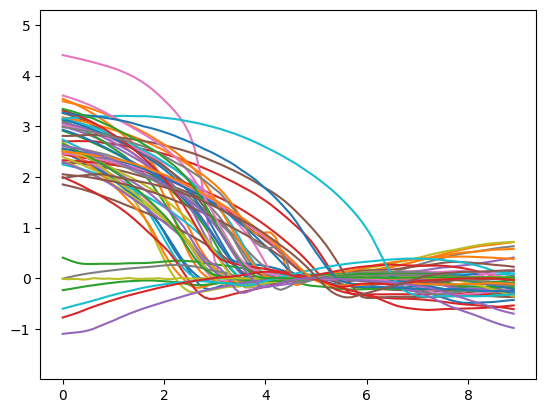

In [45]:
for i in range(len(true_inputs)):
    input_ = true_inputs[i]
    xs = np.arange(0, len(input_)) / 10
    plt.plot(xs, input_.squeeze())
    plt.axis('equal')

plt.show()

(-0.44500000000000006, 9.345, -0.25168368220329285, 0.1181609034538269)

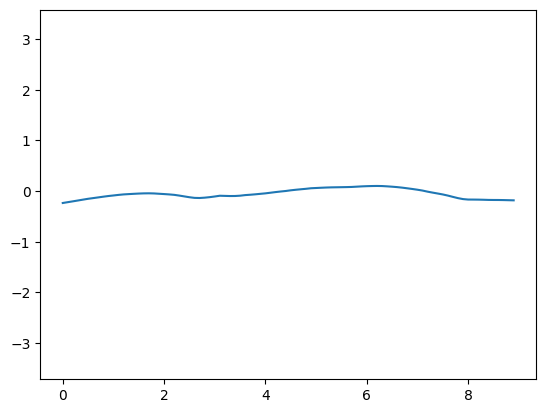

In [59]:
input_ = true_inputs[16]
xs = np.arange(0, len(input_)) / 10
plt.plot(xs, input_.squeeze())
plt.axis('equal')

In [61]:
pred_input = np.array([[-0.32886124, -0.30573928, -0.2832498 , -0.26142844, -0.24031863,
        -0.21996291, -0.20041068, -0.1817102 , -0.16390751, -0.14705364,
        -0.13120492, -0.11641731, -0.10274515, -0.09024453, -0.07897973,
        -0.06901179, -0.06040576, -0.05322429, -0.04753554, -0.04341001,
        -0.04091959, -0.04013591, -0.04113246, -0.04398653, -0.04876236,
        -0.05562274, -0.06440856, -0.07542459, -0.09124735, -0.09355835,
        -0.08660599, -0.08191811, -0.0766269 , -0.07106484, -0.06530071,
        -0.05930763, -0.0531153 , -0.04673966, -0.04020319, -0.03352798,
        -0.02673756, -0.01985845, -0.0129209 , -0.00595551,  0.00100721,
         0.00793237,  0.01478201,  0.02151763,  0.02810087,  0.03448912,
         0.04063716,  0.0464988 ,  0.05202525,  0.05716781,  0.0618742 ,
         0.06609092,  0.06975813,  0.07282092,  0.0752214 ,  0.07689557,
         0.0777764 ,  0.07780031,  0.07690296,  0.07501176,  0.07205364,
         0.06795453,  0.06264255,  0.05603837,  0.04806166,  0.03862988,
         0.02766029,  0.0150692 ,  0.0007708 , -0.01533364, -0.0333145 ,
        -0.05332041, -0.0753987 , -0.09893879, -0.1290345 , -0.14772262,
        -0.14103665, -0.1374403 , -0.13399568, -0.13009234, -0.12615888,
        -0.12207697, -0.11788097, -0.11358421, -0.10920186, -0.1047492 ]])

(-0.44500000000000006, 9.345, -0.3503717912961979, 0.12286033722015571)

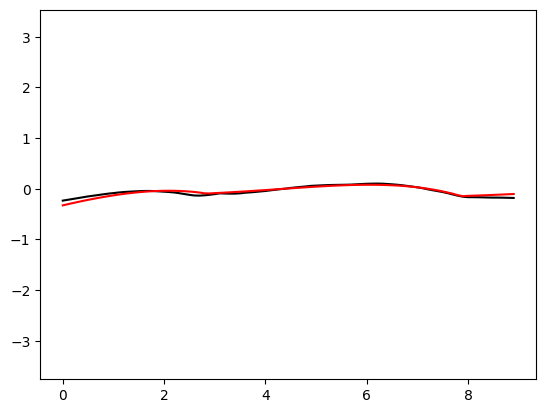

In [63]:
input_ = true_inputs[16]
xs = np.arange(0, len(input_)) / 10
plt.plot(xs, input_.squeeze(), color='black')
plt.plot(xs, pred_input.squeeze(), color='red')
plt.axis('equal')

In [64]:
from e2e.models.recurrent import LSTM
from e2e.models.modelV2 import ModelV2
import torch

LSTM_INPUT_LENGTH = 90
LSTM_TARGET_LENGTH = 90
LSTM_P = 0.5


N_PREDICTIONS = 30
DEVICE = "cpu"

lstm = LSTM(
    p=LSTM_P,
    n_input_features=LSTM_INPUT_LENGTH,
    n_output_features=LSTM_TARGET_LENGTH,
    n_hidden=LSTM_TARGET_LENGTH * 3,
    n_layers=10,
)

base = Path("/Users/magnus/repos/waam-e2e/e2e/")
lstm_path = base / Path("./waam-e2e-pre/mbw4tdhh/checkpoints/epoch=199-step=2400.ckpt")

shape_predictor = ModelV2.load_from_checkpoint(model=lstm, checkpoint_path=lstm_path, map_location=torch.device(DEVICE))
shape_predictor.eval()

2023-10-16 12:26:46,061 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmpm7m3cnwl
2023-10-16 12:26:46,062 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Writing /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmpm7m3cnwl/_remote_module_non_scriptable.py
/Users/magnus/miniconda3/envs/waam310/lib/python3.10/site-packages/lightning/pytorch/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.3, which is newer than your current Lightning version: v2.0.2
  rank_zero_warn(


ModelV2(
  (model): LSTM(
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc): Linear(in_features=90, out_features=90, bias=True)
    (bn2): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lstm): LSTM(90, 270, num_layers=10, batch_first=True, dropout=0.5)
    (fc2): Linear(in_features=270, out_features=90, bias=True)
    (combine): Linear(in_features=91, out_features=45, bias=True)
    (out): Linear(in_features=45, out_features=3, bias=True)
  )
)

In [89]:
pred_from_pred, _ = shape_predictor.predict_with_uncertainty(torch.tensor(pred_input, dtype=torch.float32).reshape(1,-1), num_samples=30)
pred_from_true, _ = shape_predictor.predict_with_uncertainty(torch.tensor(input_, dtype=torch.float32).reshape(1,-1), num_samples=30)

(-0.44500000000000006, 9.345, -0.5085108316173096, 3.443780183963501)

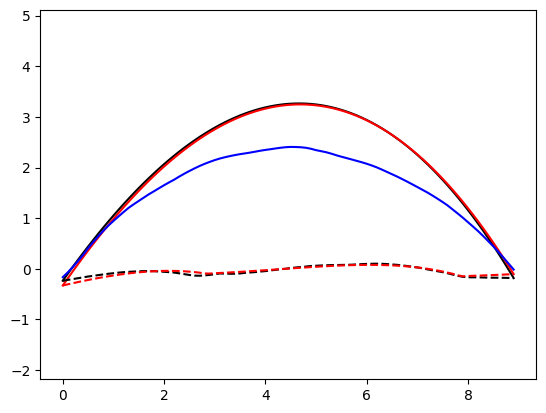

In [90]:
xs = np.arange(0, 90) / 10
plt.plot(xs, pred_from_true.numpy().squeeze(), color='black')
plt.plot(xs, pred_from_pred.numpy().squeeze(), color='red')
plt.plot(xs, input_.squeeze(), color='black', ls='--')
plt.plot(xs, pred_input.squeeze(), color='red', ls='--')
plt.plot(xs, true_outputs[16].squeeze(), color='blue')
plt.axis('equal')

In [94]:
diff = true_outputs[16].squeeze() - input_.squeeze()
diff.sum()* 0.1

14.557768262363972